# Tutorial 05


## How to deal with overfitting?

*    We want to use complex models that can learn better representations
*    We can use regularization to reduce overfitting

## Regularization

Option 1: Get more data => expensive & difficult  <br>
generate more data => **data augmentation**

Option 2: Constrain your model <br>
Make it more difficult to memorize data => **L2 regularization, Dropout, Early stopping**

### Data Augmentation

<!-- <img src="https://way2vat.com/wp-content/uploads/2018/08/cat_augment.png" width="700" />

They are all cat, in fact; they all the same cat

#### Be Careful 
<img src="https://drive.google.com/uc?export=view&id=1LljG4XTSH6RBRSD17IaX_Ror-7lg_kqX" width="700" /> -->

### Data Augmentation - Pytorch
Many of the data augmentation methods implemented in Pytorch's [torchvision / transform package](https://pytorch.org/vision/stable/transforms.html)





In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import PIL
import requests

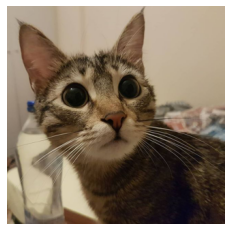

In [3]:
_img_url = "https://drive.google.com/uc?export=view&id=1WjH7avUYEOK3SPLYviG2F0IJhUTE6Yt4"
image = PIL.Image.open(requests.get(_img_url, stream=True).raw)
image = image.resize((320, 320))
plt.imshow(image)
plt.axis('off');

In [18]:
#### Implement the following transformations

### Horizontal Flip

### Random Crop

# Color Jitter

# Random Resized Crop

# Random rotation

# Random affine transform

# Composition of transforms

# Download the Dataset
We are using cats vs. dogs dataset. Dataset can be downloaded from https://www.microsoft.com/en-us/download/details.aspx?id=54765

**Data**: Labeled images of dogs and cats.  
We want to learn a **classifier**: A function that returns a label (here: `cat`/`dog`) for images

In [17]:
#### Load dataset

In [55]:
### Split the data set into train and validation

In [58]:
#### Define data loaders

### Model

In [59]:
import torch.nn as nn
    
class MLPModel(nn.Module):
    
    def __init__(self, input_dim, hidden_dim):
        super(MLPModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )
    
    def forward(self, input):
        input = input.view(input.size(0), -1)
        return self.layers(input)

## Train without regularization


In [60]:
### implement the training loop

# Early stopping
We will monitor **val_loss** and save the model with the lowest value.  
We could also stop the training if the validation loss stops decreasing

In [ ]:
### Implement training with early stopping

# Data augmentation
We will add several transformations that preserve the label (https://pytorch.org/docs/stable/torchvision/transforms.html#transforms-on-pil-image):
- Random horizontal flip
- Random crop (we will first resize to (40, 40), then take crops of size (32, 32))

In [15]:
### Implement training with data augmentation

# Dropout
We will add dropout layers after every activation function.  
Dropout documentation: https://pytorch.org/docs/stable/nn.html#torch.nn.Dropout

In [16]:
### Implement training with dropout

# Results comparison